#STEP1 :-  Importing required libraraies 

In [44]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense

In [45]:
#Step2:- loading dataset

In [46]:
# Read the CSV file containing Kathmandu air quality measurements into a DataFrame
df = pd.read_csv("/Users/nishathakur/PROJECTS/AQI_PREDICTION/DATASET/aqi_dataset.csv")
print(df)

              datetime      date  year  month  day  hour day_of_week  \
0          1/1/20 6:00    1/1/20  2020      1    1     6   Wednesday   
1          1/1/20 6:00    1/1/20  2020      1    1     6   Wednesday   
2          1/1/20 6:00    1/1/20  2020      1    1     6   Wednesday   
3          1/1/20 6:00    1/1/20  2020      1    1     6   Wednesday   
4          1/1/20 6:00    1/1/20  2020      1    1     6   Wednesday   
...                ...       ...   ...    ...  ...   ...         ...   
201659  12/31/25 23:00  12/31/25  2025     12   31    23   Wednesday   
201660  12/31/25 23:00  12/31/25  2025     12   31    23   Wednesday   
201661  12/31/25 23:00  12/31/25  2025     12   31    23   Wednesday   
201662  12/31/25 23:00  12/31/25  2025     12   31    23   Wednesday   
201663  12/31/25 23:00  12/31/25  2025     12   31    23   Wednesday   

        is_weekend  season       city  ...    no2   so2    co    o3  \
0                0  winter      Delhi  ...  119.6  47.7  5.19  1

In [47]:
print("Length of the dataset: ", len(df), "\n\n")
df.head()

Length of the dataset:  201664 




,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,1/1/20 6:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,1/1/20 6:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe
2,1/1/20 6:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Delhi,...,121.5,42.4,4.76,14.3,6.1,100,4.2,1.0,500,Severe
3,1/1/20 6:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Delhi,...,111.6,29.4,5.79,17.1,6.2,100,2.5,1.1,500,Severe
4,1/1/20 6:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Delhi,...,115.2,30.3,5.01,24.8,7.6,100,3.6,2.2,500,Severe


In [48]:
df.columns

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')

#STEP3:-Selection of Releveant pollutant Variable 

In [49]:
# # keep only the rows where the 'parameter' column is 'Gurugram Vikas Sadan'
# # This remove other pollutants if they exist (e.g., o3, etc.)
# GurugramVikasSadan_df = df[df["station"] == "Gurugram Vikas Sadan"].copy()
# print("Lengh of the dataset: ", len(Gurugram Vikas Sadan), "\n\n")
# GurugramVikasSadan_df.head


# keep only the rows where the 'station' column is 'Gurugram Vikas Sadan'
# This removes other stations if they exist

GurugramVikasSadan_df = df[df["station"] == "Gurugram Vikas Sadan"].copy()

print("Length of the dataset:", len(GurugramVikasSadan_df), "\n\n")

GurugramVikasSadan_df.head()


Length of the dataset: 8768 




,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
17,1/1/20 6:00,1/1/20,2020,1,1,6,Wednesday,0,winter,Gurugram,...,119.5,27.7,6.40,15.7,6.9,100,2.7,1.2,500,Severe
40,1/1/20 12:00,1/1/20,2020,1,1,12,Wednesday,0,winter,Gurugram,...,97.0,17.7,3.02,28.9,20.7,55,6.2,1.3,435,Severe
63,1/1/20 18:00,1/1/20,2020,1,1,18,Wednesday,0,winter,Gurugram,...,152.5,31.6,6.42,15.5,14.6,46,4.9,1.0,500,Severe
86,1/1/20 23:00,1/1/20,2020,1,1,23,Wednesday,0,winter,Gurugram,...,100.0,27.9,4.66,24.3,12.4,54,6.2,1.6,470,Severe
109,1/2/20 6:00,1/2/20,2020,1,2,6,Thursday,0,winter,Gurugram,...,134.2,26.8,5.33,15.2,9.6,100,4.1,1.4,500,Severe


In [50]:
GurugramVikasSadan_df[GurugramVikasSadan_df["station"] == "GurugramVikasSadan"]

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category


In [51]:
GurugramVikasSadan_df["station"]
# df.columns("station")

17        Gurugram Vikas Sadan
40        Gurugram Vikas Sadan
63        Gurugram Vikas Sadan
86        Gurugram Vikas Sadan
109       Gurugram Vikas Sadan
                  ...         
201566    Gurugram Vikas Sadan
201589    Gurugram Vikas Sadan
201612    Gurugram Vikas Sadan
201635    Gurugram Vikas Sadan
201658    Gurugram Vikas Sadan
Name: station, Length: 8768, dtype: object

In [52]:
df["station"].iloc[0:25]


0       Anand Vihar, Delhi
1      Jahangirpuri, Delhi
2          Wazirpur, Delhi
3            Bawana, Delhi
4               ITO, Delhi
5      Punjabi Bagh, Delhi
6     Okhla Phase 2, Delhi
7          Shadipur, Delhi
8            Rohini, Delhi
9          RK Puram, Delhi
10        Siri Fort, Delhi
11     Dwarka Sec 8, Delhi
12      NSIT Dwarka, Delhi
13      Mandir Marg, Delhi
14            Noida Sec 62
15           Noida Sec 125
16           Greater Noida
17    Gurugram Vikas Sadan
18         Gurugram Sec 51
19       Faridabad Sec 16A
20      Faridabad New Town
21    Ghaziabad Vasundhara
22          Ghaziabad Loni
23      Anand Vihar, Delhi
24     Jahangirpuri, Delhi
Name: station, dtype: object

In [53]:
GurugramVikasSadan_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 8768 entries, 17 to 201658
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datetime      8768 non-null   object 
 1   date          8768 non-null   object 
 2   year          8768 non-null   int64  
 3   month         8768 non-null   int64  
 4   day           8768 non-null   int64  
 5   hour          8768 non-null   int64  
 6   day_of_week   8768 non-null   object 
 7   is_weekend    8768 non-null   int64  
 8   season        8768 non-null   object 
 9   city          8768 non-null   object 
 10  station       8768 non-null   object 
 11  latitude      8768 non-null   float64
 12  longitude     8768 non-null   float64
 13  pm25          8768 non-null   float64
 14  pm10          8768 non-null   float64
 15  no2           8768 non-null   float64
 16  so2           8768 non-null   float64
 17  co            8768 non-null   float64
 18  o3            8768 non-null   

In [64]:
# convert 'datetime' from string to datetime objects

GurugramVikasSadan_df["datetime"] = pd.to_datetime(
    GurugramVikasSadan_df["datetime"],
    format="%m/%d/%y %H:%M"
)
#12/31/25 23:00


In [55]:
print(GurugramVikasSadan_df)

              datetime      date  year  month  day  hour day_of_week  \
17         1/1/20 6:00    1/1/20  2020      1    1     6   Wednesday   
40        1/1/20 12:00    1/1/20  2020      1    1    12   Wednesday   
63        1/1/20 18:00    1/1/20  2020      1    1    18   Wednesday   
86        1/1/20 23:00    1/1/20  2020      1    1    23   Wednesday   
109        1/2/20 6:00    1/2/20  2020      1    2     6    Thursday   
...                ...       ...   ...    ...  ...   ...         ...   
201566  12/30/25 23:00  12/30/25  2025     12   30    23     Tuesday   
201589   12/31/25 6:00  12/31/25  2025     12   31     6   Wednesday   
201612  12/31/25 12:00  12/31/25  2025     12   31    12   Wednesday   
201635  12/31/25 18:00  12/31/25  2025     12   31    18   Wednesday   
201658  12/31/25 23:00  12/31/25  2025     12   31    23   Wednesday   

        is_weekend  season      city  ...    no2   so2    co    o3  \
17               0  winter  Gurugram  ...  119.5  27.7  6.40  15.

In [56]:
#Remove columns that are not needed for this analysis to simplify the dataset



#Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       #'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       #'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       #'wind_speed', 'visibility', 'aqi', 'aqi_category'],
       #dtype='object')




GurugramVikasSadan_df = GurugramVikasSadan_df.drop(columns = ["date","year","month","day","hour","day_of_week","city","station","latitude","longitude"])
GurugramVikasSadan_df.head()                                                              
                                    


,datetime,is_weekend,season,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
17,1/1/20 6:00,0,winter,385.0,703.0,119.5,27.7,6.40,15.7,6.9,100,2.7,1.2,500,Severe
40,1/1/20 12:00,0,winter,237.2,458.1,97.0,17.7,3.02,28.9,20.7,55,6.2,1.3,435,Severe
63,1/1/20 18:00,0,winter,306.6,515.3,152.5,31.6,6.42,15.5,14.6,46,4.9,1.0,500,Severe
86,1/1/20 23:00,0,winter,285.1,486.2,100.0,27.9,4.66,24.3,12.4,54,6.2,1.6,470,Severe
109,1/2/20 6:00,0,winter,355.1,585.4,134.2,26.8,5.33,15.2,9.6,100,4.1,1.4,500,Severe


In [57]:
# If you want to check how many AQI values are equal to 500 in your dataset, use counting with a condition.
(GurugramVikasSadan_df["aqi"]==500).sum()


np.int64(1826)

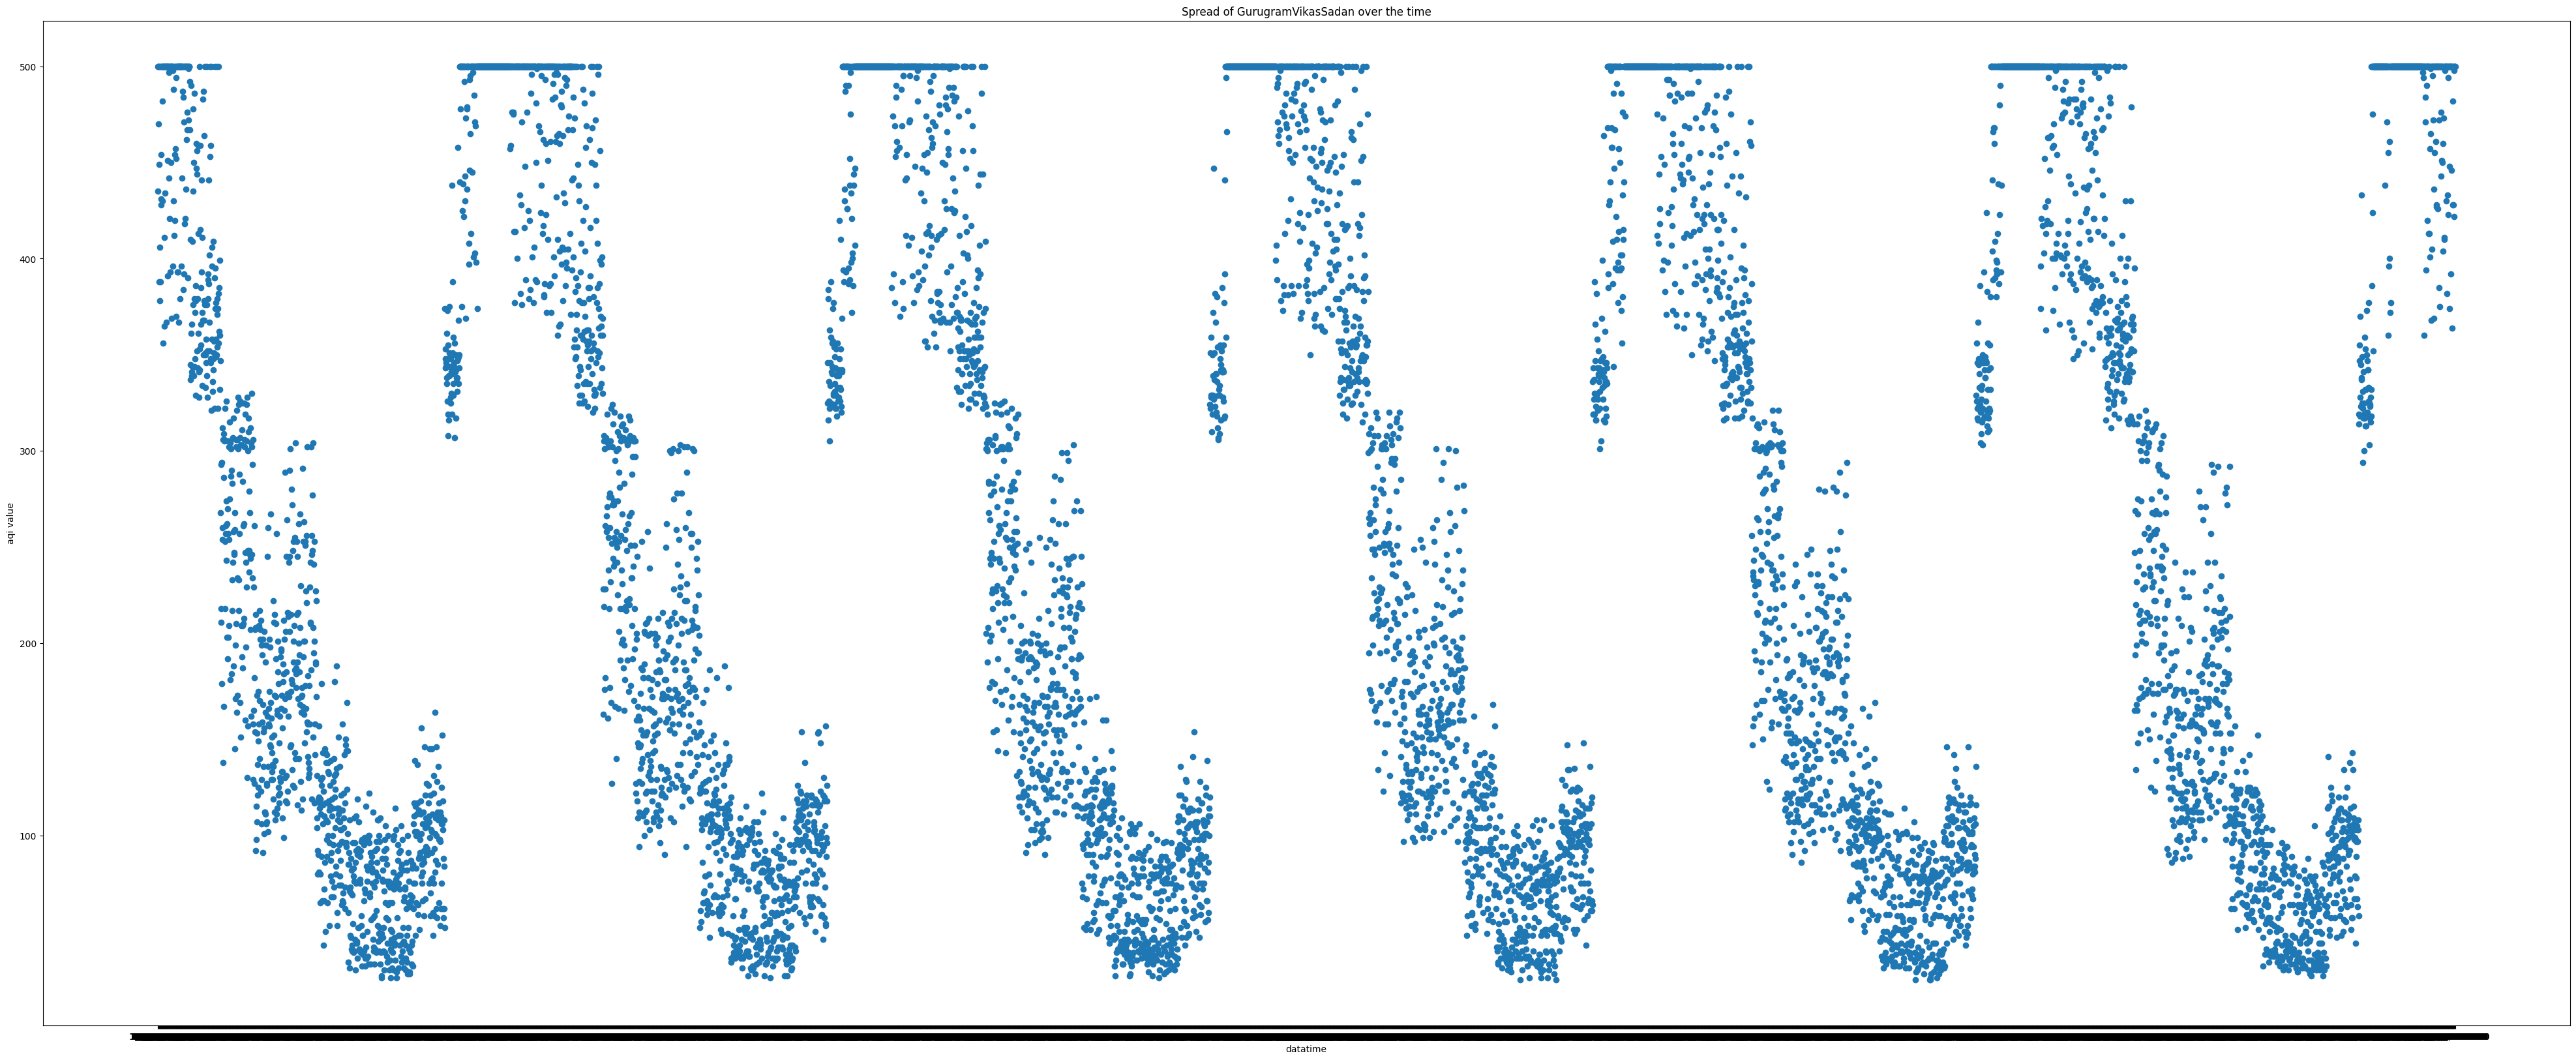

In [58]:
#Create a large scatter plot of GurugramVikasSadan values over local time for the full time series
plt.figure(figsize=(50, 20))
plt.scatter(GurugramVikasSadan_df["datetime"], GurugramVikasSadan_df["aqi"])
plt.title("Spread of GurugramVikasSadan over the time")
plt.xlabel("datatime")
plt.ylabel("aqi value")
plt.show()
           

In [87]:
df = GurugramVikasSadan_df

In [88]:
# In reality, GurugramVikasSadan levels never drop to zero. 
# Furthermore, there is no historical record of concentrations exceeding $370 µg/m³$ in Kathmandu. 
# Values outside this range are likely sensor errors; therefore, we will treat them as outliers 
# and use backfill (bfill) followed by forward fill (ffill) to impute the missing data.

# Count's how many values are abnormally high (> 500)
count = (GurugramVikasSadan_df["aqi"] >500).sum()

# Why 102 and why not 100 ?
# Selected 102 as the upper threshold based on model tuning. While 100 is standard, 
# 102 optimized the r^2 score, preserving valid high-pollution peaks while removing true sensor noise.

print("No of outliers/invalid data in GurugramVikasSadan:" ,count)

# Count's how many values are zero or negative (physically impossible for concentration)
negative_GurugramVikasSadan_values = (GurugramVikasSadan_df["aqi"] <= 0).sum()
print("No of negative/invalid data in GurugramVikasSadan:" ,negative_GurugramVikasSadan_values)

No of outliers/invalid data in GurugramVikasSadan: 0
No of negative/invalid data in GurugramVikasSadan: 0


In [89]:
# # create a binary flage columns where 1 means the sensor is "down" ( invalid/NAN clean_value) and 0 means the sensor is working normally 
# pm25_df["sensor_down"] = pm25_df["clean_value"].isna().astype(int)
# print(pm25_df[["local", "clean_value","value","parameter","sensor_down"]].sort_values(by="value", ascending=False.head())



In [90]:
# # Create binary flag column
# pm25_df["sensor_down"] = pm25_df["clean_value"].isna().astype(int)

# # Print sorted values
# print(
#     pm25_df[["local", "clean_value", "value", "parameter", "sensor_down"]]
#     .sort_values(by="value", ascending=False)
#     .head()
)


SyntaxError: unmatched ')' (2315527043.py, line 9)

In [91]:
sensor_columns = [
    "pm25", "pm10", "no2", "so2",
    "co", "o3", "temperature",
    "humidity", "wind_speed", "visibility"
]

for col in sensor_columns:
        df[col + "_down"] = df[col].isna().astype(int) # if NAN value are their then 0 or hisab se rakha de tai 


In [92]:
df

,datetime,is_weekend,season,pm25,pm10,no2,so2,co,o3,temperature,...,pm25_down,pm10_down,no2_down,so2_down,co_down,o3_down,temperature_down,humidity_down,wind_speed_down,visibility_down
17,2020-01-01 06:00:00,0,winter,385.0,703.0,119.5,27.7,6.40,15.7,6.9,...,0,0,0,0,0,0,0,0,0,0
40,2020-01-01 12:00:00,0,winter,237.2,458.1,97.0,17.7,3.02,28.9,20.7,...,0,0,0,0,0,0,0,0,0,0
63,2020-01-01 18:00:00,0,winter,306.6,515.3,152.5,31.6,6.42,15.5,14.6,...,0,0,0,0,0,0,0,0,0,0
86,2020-01-01 23:00:00,0,winter,285.1,486.2,100.0,27.9,4.66,24.3,12.4,...,0,0,0,0,0,0,0,0,0,0
109,2020-01-02 06:00:00,0,winter,355.1,585.4,134.2,26.8,5.33,15.2,9.6,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201566,2025-12-30 23:00:00,0,winter,336.0,588.4,140.0,23.9,4.07,15.9,15.8,...,0,0,0,0,0,0,0,0,0,0
201589,2025-12-31 06:00:00,0,winter,265.8,447.7,96.9,22.0,3.70,28.2,8.7,...,0,0,0,0,0,0,0,0,0,0
201612,2025-12-31 12:00:00,0,winter,265.0,525.8,75.5,14.9,4.14,23.1,21.2,...,0,0,0,0,0,0,0,0,0,0
201635,2025-12-31 18:00:00,0,winter,299.4,634.0,121.8,25.7,5.86,29.3,17.5,...,0,0,0,0,0,0,0,0,0,0


In [93]:
# step :- 2 if you want one combined sensor status column 1= any sensor is down and 0 = all sensors working 
df["sensor_down"] = (
       df[sensor_columns].isna().any(axis=1)
).astype(int)


In [94]:
# check 
df[["pm25", "pm10", "sensor_down"]].head()


,pm25,pm10,sensor_down
17,385.0,703.0,0
40,237.2,458.1,0
63,306.6,515.3,0
86,285.1,486.2,0
109,355.1,585.4,0


In [95]:
down_columns = [col for col in df.columns if col.endswith("_down")]

print(df[down_columns].head())


     pm25_down  pm10_down  no2_down  so2_down  co_down  o3_down  \
17           0          0         0         0        0        0   
40           0          0         0         0        0        0   
63           0          0         0         0        0        0   
86           0          0         0         0        0        0   
109          0          0         0         0        0        0   

     temperature_down  humidity_down  wind_speed_down  visibility_down  \
17                  0              0                0                0   
40                  0              0                0                0   
63                  0              0                0                0   
86                  0              0                0                0   
109                 0              0                0                0   

     sensor_down  
17             0  
40             0  
63             0  
86             0  
109            0  


In [96]:
down_columns.info()

AttributeError: 'list' object has no attribute 'info'

In [97]:
# PM2.5 Outlier Handling

count_pm25 = ((df["pm25"] < 0) | (df["pm25"] > 250)).sum()
print("PM2.5 Outliers:", count_pm25)

df.loc[(df["pm25"] < 0) | (df["pm25"] > 250), "pm25"] = None
df["pm25"] = df["pm25"].bfill().ffill()


PM2.5 Outliers: 2163


In [98]:
count_pm10 = ((df["pm10"] < 0) | (df["pm10"] > 430)).sum()
print("PM10 Outliers:", count_pm10)

df.loc[(df["pm10"] < 0) | (df["pm10"] > 430), "pm10"] = None
df["pm10"] = df["pm10"].bfill().ffill()


PM10 Outliers: 2495


In [99]:
count_no2 = ((df["no2"] < 0) | (df["no2"] > 400)).sum()
print("NO2 Outliers:", count_no2)

df.loc[(df["no2"] < 0) | (df["no2"] > 400), "no2"] = None
df["no2"] = df["no2"].bfill().ffill()


NO2 Outliers: 41


In [100]:
count_so2 = ((df["so2"] < 0) | (df["so2"] > 800)).sum()
print("SO2 Outliers:", count_so2)

df.loc[(df["so2"] < 0) | (df["so2"] > 800), "so2"] = None
df["so2"] = df["so2"].bfill().ffill()


SO2 Outliers: 0


In [101]:
count_co = ((df["co"] < 0) | (df["co"] > 34)).sum()
print("CO Outliers:", count_co)

df.loc[(df["co"] < 0) | (df["co"] > 34), "co"] = None
df["co"] = df["co"].bfill().ffill()


CO Outliers: 0


In [102]:
count_o3 = ((df["o3"] < 0) | (df["o3"] > 748)).sum()
print("O3 Outliers:", count_o3)

df.loc[(df["o3"] < 0) | (df["o3"] > 748), "o3"] = None
df["o3"] = df["o3"].bfill().ffill()


O3 Outliers: 0


In [103]:
count_temp = ((df["temperature"] < -10) | (df["temperature"] > 50)).sum()
print("Temperature Outliers:", count_temp)

df.loc[(df["temperature"] < -10) | (df["temperature"] > 50), "temperature"] = None
df["temperature"] = df["temperature"].bfill().ffill()


Temperature Outliers: 0


In [104]:
count_humidity = ((df["humidity"] < 0) | (df["humidity"] > 100)).sum()
print("Humidity Outliers:", count_humidity)

df.loc[(df["humidity"] < 0) | (df["humidity"] > 100), "humidity"] = None
df["humidity"] = df["humidity"].bfill().ffill()


Humidity Outliers: 0


In [105]:
count_wind = ((df["wind_speed"] < 0) | (df["wind_speed"] > 60)).sum()
print("Wind Speed Outliers:", count_wind)

df.loc[(df["wind_speed"] < 0) | (df["wind_speed"] > 60), "wind_speed"] = None
df["wind_speed"] = df["wind_speed"].bfill().ffill()


Wind Speed Outliers: 0


In [106]:
count_visibility = ((df["visibility"] < 0) | (df["visibility"] > 20)).sum()
print("Visibility Outliers:", count_visibility)

df.loc[(df["visibility"] < 0) | (df["visibility"] > 20), "visibility"] = None
df["visibility"] = df["visibility"].bfill().ffill()


Visibility Outliers: 0
